# LSC Final Project
**Group 11**
Siamak Seifi, Amir Mashmool

**Title:** The GraphFrames API

Category A (APIs of the Spark ecosystems: advanced aspects of RDD/Dataframe/ SparkSQL/streaming Spark, libraries such as GraphX and Mllib)

### Initial setup

In [1]:
# Download and install the required packages
!pip install pyspark > /dev/null
!pip install graphframes > /dev/null
# !wget -P "/usr/local/lib/python3.6/dist-packages/pyspark/jars/" https://repos.spark-packages.org/graphframes/graphframes/0.8.1-spark3.0-s_2.12/graphframes-0.8.1-spark3.0-s_2.12.jar
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages graphframes:graphframes:0.8.1-spark3.0-s_2.12 pyspark-shell'

In [2]:
# Import modules
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession, SQLContext
from pyspark.sql.types import *
import pyspark.sql.functions as f
from graphframes import *

In [3]:
# Init Spark session
spark = SparkSession.builder.master("local[*]")\
.config("spark.jars.packages", "graphframes:graphframes:0.8.1-spark3.0-s_2.12").getOrCreate()
sc = spark.sparkContext
sqlContext = SQLContext(sc)

/usr/local/lib/python3.7/dist-packages/pyspark/sql/context.py:79: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  FutureWarning


# GraphFrames
Apache Spark GraphX made it possible to run graph algorithms within Spark. GraphFrames integrates GraphX and DataFrames and makes it possible to perform Graph pattern queries without moving data to a specialized graph database.
GraphFrames is a Spark package that provides the necessary tools for the storage and manipulation of large graph structures. It implements the GraphFrame class, which uses DataFrames to store the graph data and offers several methods for extracting information.

## Why graphs?
Graphs provide a powerful way to analyze the connections in a Dataset. GraphX is the Apache Spark component for graph-parallel and data-parallel computations, built upon a branch of mathematics called graph theory. It is a distributed graph processing framework that sits on top of the Spark core. GraphX brings the speed and scalability of parallel, iterative processing to graphs for big datasets. It partitions graphs that are too large to fit in the memory of a single computer among multiple computers in a cluster. In addition, GraphX partitions vertices independently of edges, which avoids the load imbalance often suffered when putting all the edges for a vertex onto a single machine.
Examples of connected data that can be represented by graphs include:

*   **Recommendation systems**, Recommendation algorithms can use graphs where the nodes are the users and products, and their respective attributes and the edges are the ratings or purchases of the products by users. Graph algorithms can calculate weights for how similar users rated or purchased similar products.
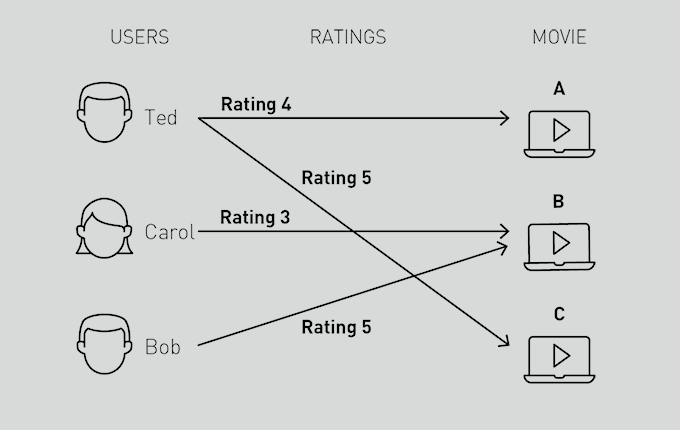
*   **Fraud detection systems**. Graphs are useful for fraud detection algorithms in banking, healthcare, and network security. In healthcare, graph algorithms can explore the connections between patients, doctors, and pharmacy prescriptions. In banking, graph algorithms can explore the relationship between credit card applicants and phone numbers and addresses or between credit cards customers and merchant transactions. In network security, graph algorithms can explore data breaches.
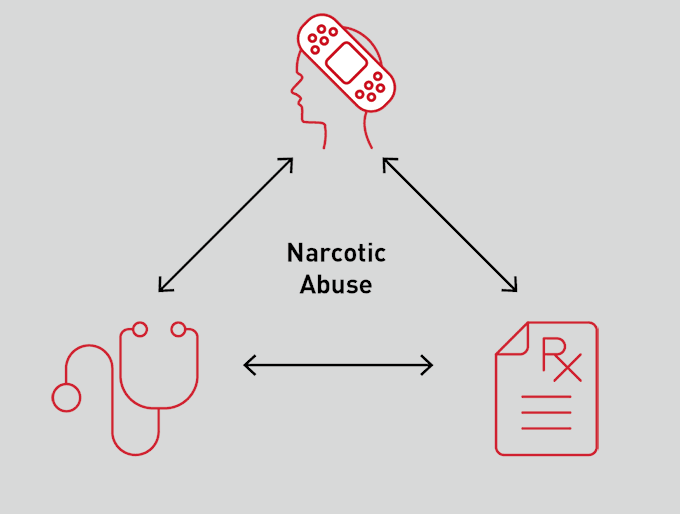
*   **Search engines**, A company as big as Google uses Algorithms such as PageRank (which will be presented further in the lab) to determine how reputable a page is; to apply the algorithm, it is necessary to construct a directed graph with webpages as vertices and links as edges.

## PageRank
PageRank is an algorithm that determines how "relevant" each vertex in a graph is. It was the first ranking algorithm driving Google's search engine, and it is still in use to this day, although it is not the only ranking parameter in Google Search anymore.

The algorithm starts from a directed graph in which vertices are pages and edges are links between pages. Multiple links from a page to another count as a single edge.
The core assumptions are that important pages have **many links** pointing to them, and that links coming from important pages are **worth more** than those from unimportant pages.

Each vertex $v\in V$ is assigned an importance value $PR(v)$ that ranges from 0 to 1. The algorithm is designed to mimic a user's "**random surfing**" through the web, and $PR(v)$ corresponds to the probability a user has to land on page $v$ by following links. As such, PageRank forms a **probability distribution** over the nodes in the network ($\sum_{v\in V}PR(v)=1$).

The model also takes into account a ***damping factor*** $d\in[0,1]$ that represents the erratic behaviour of users; $(1-d)$ is the probability that the random surfer will not follow any of the links in the current page and instead jump to another random page in the graph. The original research paper suggests the value $d=0.85$ for all pages.

PageRank is an iterative algorithm: initially, every page is assigned the same ranking $1/N$, where $N$ is the total number of pages. Given a page $a\in V$, let us denote with $I(a)$ the set of all pages pointing to $a$, and with $O(a)$ the set of all pages that $a$ points to. At each iteration, the scoring of every node $v$ is recalculated based according to the following formula:
$$PR(v) = \frac{(1-d)}{N} + d \sum_{u\in I(v)} \frac{PR(u)}{|O(u)|}$$

Some comments are in order. First, notice how a damping factor smaller than one grants a fixed "minimum importance" to every page, as the page can always be reached directly even if there are no links pointing to it. Then, observe that the amount of importance transferred to linked pages is inversely proportional to the number of outgoing links; this means that a page with links to a lot of other pages will have negligible effects on the PageRank of those pages.

Clearly, all these scenarios involve huge amounts of data, hence the need for a **large-scale implementation** of graph structures.

## Basics of GraphFrames
The core class of GraphFrames is called, unsuprisingly, `GraphFrame`. As its name suggests, it is based on the DataFrame API of Spark. In fact, a GraphFrame is constructed from two DataFrames, one for the vertices and one for the edges, which must contain **special columns** to comply with the graph structure.

*   The vertices Dataframe must have a column named "id", which can be of any type and represents the unique identifier for each vertex.
*   The edges DataFrame must have two columns named "src" and "dst", which represent the start and end points of the edge respectively. The values in these two columns must be taken from the unique vertex IDs provided in the other DataFrame.

While these columns are required, it is important to notice that both vertices and edges can carry an arbitrary number of additional attributes. Note that we will always consider directed graphs.

## Description of the dataset
The two provided files `vertices.csv` and `edges.csv` contain the dataset used throughout the notebook for examples and exercises. The data is structured as follows:
*   vertices have the attributes "id", "name", and "age";
*   edges have the attributes "src", "dest", and "relation"; for each edge, the latter can be either *follow* or *like*.

The data itself represents an imaginary social network with 30 users (vertices) who have two ways of interacting: they can *follow* and *like* eachother, and these relations form the edge set of the (directed) graph. Each user is identified by a unique ID, as required by the API.


In [4]:
# Create and show DataFrames
# Vertices
schema_v = StructType()\
         .add('id', IntegerType())\
         .add('name', StringType())\
         .add('age', IntegerType())
vertices_df = spark.read.csv('/content/drive/MyDrive/Colab Data/vertices.csv', schema_v)

#Edges
schema_e = StructType()\
         .add('src', IntegerType())\
         .add('dst', IntegerType())\
         .add('relation', StringType())
edges_df = spark.read.csv('/content/drive/MyDrive/Colab Data/edges.csv', schema_e)

vertices_df.show(5)
edges_df.show(10)

# Create GraphFrame
g = GraphFrame(vertices_df, edges_df)
print(g)

+---+-----------+---+
| id|       name|age|
+---+-----------+---+
|  1|     Andrew| 31|
|  2|    Anthony| 24|
|  3|      Brian| 46|
|  4|    Charles| 36|
|  5|Christopher| 23|
+---+-----------+---+
only showing top 5 rows

+---+---+--------+
|src|dst|relation|
+---+---+--------+
|  1|  3|  follow|
|  1|  5|    like|
|  1| 20|  follow|
|  1| 23|    like|
|  1| 25|  follow|
|  1| 27|    like|
|  2|  6|  follow|
|  2|  7|    like|
|  2| 10|  follow|
|  2| 12|  follow|
+---+---+--------+
only showing top 10 rows

GraphFrame(v:[id: int, name: string ... 1 more field], e:[src: int, dst: int ... 1 more field])


### Querying the vertex and edge sets
The API provides a simple way to access vertex and edge data; since it is stored on DataFrames, one can easily run standard Spark queries on the vertices and edges of a graph by accessing the `vertices` and `edges` fields:

In [7]:
# Count vertices and edges
print("Total number of vertices in graph:", g.vertices.count())
print("Total number of edges in graph:", g.edges.count())

# Show name and age of the 10 youngest people
g.vertices.select('name','age').orderBy('age').show(10)

# Count like and follow relationships
print("Total number of follow relationship in graph:",
        g.edges.filter("relation = 'follow'").count())
print("Total number of like relationship in graph:",
        g.edges.filter("relation = 'like'").count())

Total number of vertices in graph: 30
Total number of edges in graph: 200
+-----------+---+
|       name|age|
+-----------+---+
|    Timothy| 20|
|    Kenneth| 21|
|Christopher| 23|
|     Joseph| 23|
|     Ronald| 23|
|      James| 24|
|    Anthony| 24|
|       Mark| 25|
|    Michael| 26|
|      Jason| 30|
+-----------+---+
only showing top 10 rows

Total number of follow relationship in graph: 117
Total number of like relationship in graph: 83


### Vertex degree
GraphFrames has three queries for calculating node degree. They return a dataframe with two columns: an "id" column holding the ID of each vertex, and a column named "degree" (or "inDegree" or "outDegree") which contains the degree of each vertex.
*   `inDegrees` yields the number of incoming edges to each vertex;
*   `outDegrees` yields the number of outgoing edges from each vertex;
*   `degrees` yields the sum of the in-degree and out-degree of each vertex.


In [8]:
%%time
# Find the 5 most active users (people with the most followers and likes)
rel_df = g.degrees    #find number of relations for each user

rel_df.join(g.vertices, rel_df.id == g.vertices.id) \
    .select(rel_df["degree"], g.vertices["name"]) \
    .orderBy(f.col("degree").desc()) \
    .show(5)

+------+-----------+
|degree|       name|
+------+-----------+
|    17|     Robert|
|    16|       Ryan|
|    16|    Matthew|
|    16|Christopher|
|    16|    Charles|
+------+-----------+
only showing top 5 rows

CPU times: user 25.8 ms, sys: 1.95 ms, total: 27.7 ms
Wall time: 2.12 s


### Subgraphs
The Graphframe class has methods for vertex and edge filtering, which can be used to construct subgraphs.
*   `filterVertices` removes all vertices not satisfying a condition, as well as those edges that contained filtered vertices (i.e. it returns the subgraph induced by the set of vertices satisfying the condition);
*   `filterEdges` removes all edges not satisfying a condition, but keeps all the vertices;
*   `dropIsolatedVertices` removes vertices that are not contained in any edge; it can be used in conjunction with `filterEdges` to construct edge-induced subgraphs.

In [9]:
%%time
# Find the 5 users who have the most followers and those who follow others most.
# Remove edges with tag 'like'
follow_g = g.filterEdges("relation = 'follow'")

# Find people with more followers
followers_df = follow_g.inDegrees

print("Top 5 users with most followers:")
followers_df.join(follow_g.vertices, followers_df.id == follow_g.vertices.id) \
            .select(followers_df["inDegree"], follow_g.vertices["name"]) \
            .orderBy(f.col("inDegree").desc()) \
            .show(5)

# Find people who follow others the most
following_df = follow_g.outDegrees

print("Top 5 users who follow the most people:")
following_df.join(follow_g.vertices, following_df.id == follow_g.vertices.id) \
            .select(following_df["outDegree"], follow_g.vertices["name"]) \
            .orderBy(f.col("outDegree").desc()) \
            .show(5)

Top 5 users with most followers:
+--------+-------+
|inDegree|   name|
+--------+-------+
|       7| George|
|       7| Daniel|
|       6|  Brian|
|       6|Kenneth|
|       6|Anthony|
+--------+-------+
only showing top 5 rows

Top 5 users who follow the most people:
+---------+-------+
|outDegree|   name|
+---------+-------+
|        7|   Ryan|
|        7|Jeffrey|
|        7| Robert|
|        6|Matthew|
|        6|  David|
+---------+-------+
only showing top 5 rows

CPU times: user 34.5 ms, sys: 5.97 ms, total: 40.5 ms
Wall time: 2.27 s


### PageRank in GraphFrames
The GraphFrame class has the aptly named method `pageRank`, which returns a copy of the calling GraphFrame with two additions: a "pageRank" column in the vertex DataFrame, and a "weight" column in the edge DataFrame that we will ignore for the sake of this tutorial.

This PageRank implementation allows the user to set the damping factor $d$ (through the `resetProbability` parameter, which is actually equal to $1-d$). The algorithm must be set to terminate either after a certain number of iterations (`maxIter` parameter) or when a convergence condition is met (`tol` parameter).

Lastly, notice how the sum of all scores is not equal to 1, but rather to the total number of vertices. This is just a rescaled result which prevents scores from getting too small when the graph is large.

In [10]:
%%time
# Find the most popular users in the social network according to PageRank.
pop_usrs  = g.pageRank(maxIter=20)
print("Most popular users:")
pop_usrs.vertices.select('name','pagerank') \
              .orderBy(f.col("pagerank").desc()) \
              .show(30)

Most popular users:
+-----------+------------------+
|       name|          pagerank|
+-----------+------------------+
|       Mark|1.8329716117287513|
|     Joseph|1.3480725955057609|
|      Brian|1.3165672040609488|
|     George|1.2034491620987506|
|       Paul| 1.198415687612761|
|    Matthew| 1.179884860898912|
|     Steven|1.1435265540737733|
|      James|1.1399040259508508|
|    Richard|1.0866543251785956|
|     Daniel|1.0734459478450726|
|     Donald| 1.071467639582573|
|    Kenneth| 1.063136868957977|
|    Michael|1.0623865711428147|
|     Edward|1.0528038124000632|
|     Thomas|1.0269820127107538|
|     Robert|1.0202378523981432|
|      Kevin|1.0152366783228675|
|       John|1.0012256502316845|
|    Charles|0.9833676857197312|
|     Joshua|0.9744864915947578|
|    Anthony|0.9712098942476457|
|       Ryan|0.8872203668160715|
|      Jason|0.8853107602606961|
|Christopher| 0.870989323755407|
|    Timothy|0.6971932427046239|
|    William| 0.665143564462677|
|     Andrew|0.61639285

### Other functionalities
In this notebook we covered the very basics of this powerful API. We also determined how to do pageRank with this very powerful tool. But GraphFrames also offers other features such as:
*   persistence operations;
*   motif finding (i.e. pattern matching);
*   connected and strongly connected components;
*   breadth-first search;
*   shortest paths;
*   triangle count.

which is what I advise you to go after next.

### Exercises
1. Find the least popular user.

In [11]:
%%time
pop_ppl = g.inDegrees
least_pop_user = pop_ppl \
          .join(g.vertices,pop_ppl.id == g.vertices.id) \
          .select(pop_ppl["*"],g.vertices["name"]) \
          .sort("inDegree") \
          .first()
print("The least popular user is", least_pop_user.name)

The least popular user is Jeffrey
CPU times: user 20.3 ms, sys: 0 ns, total: 20.3 ms
Wall time: 1.02 s


### Exercises
2. Find the 5 users with most like interactions.

In [15]:
%%time
likes_g = g.filterEdges("relation = 'like'")
likes_df = likes_g.degrees
print("Top 5 people who have more like interactions: ")
likes_df.join(g.vertices, likes_df.id == g.vertices.id) \
              .select(likes_df["*"], g.vertices["name"]) \
              .orderBy(f.col("degree").desc()) \
              .show(5)

Top 5 people who have more like interactions: 
+---+------+-----------+
| id|degree|       name|
+---+------+-----------+
| 19|     9|       Mark|
|  5|     9|Christopher|
| 23|     9|    Richard|
|  9|     8|     Edward|
|  7|     8|      David|
+---+------+-----------+
only showing top 5 rows

CPU times: user 14.8 ms, sys: 4.31 ms, total: 19.1 ms
Wall time: 1.08 s


### Exercises
3. List all of Steven's followers.

In [16]:
%%time
id = g.filterVertices("name = 'Steven'").vertices.first().id
followers = g.filterEdges("relation = 'follow'") \
              .filterEdges(f"dst = '{str(id)}'") \
              .dropIsolatedVertices()
print("List of Steven's followers")
followers.filterVertices("name != 'Steven'") \
              .vertices \
              .select('name') \
              .show()

List of Steven's followers
+-------+
|   name|
+-------+
|  Brian|
|Jeffrey|
| Joseph|
|Richard|
+-------+

CPU times: user 21.4 ms, sys: 9.7 ms, total: 31.1 ms
Wall time: 841 ms


### Exercises
4. Find total number of follow relations among people younger than 30.

In [17]:
%%time
c = g.filterVertices("age < 30").filterEdges("relation == 'follow'").edges.count()
print("Total number of follow relations between youngsters:", c)

Total number of follow relations between youngsters: 12
CPU times: user 8.08 ms, sys: 1.65 ms, total: 9.74 ms
Wall time: 579 ms


### Exercises
5. Show members of each community, and the number of users in each community.

In [20]:
%%time
communities = g.labelPropagation(5)
comm_labels = communities.select('label').distinct().collect()  #find labels

for n in comm_labels:   #filter and show results
    n=n[0]
    c = communities.filter(f"label = '{n}'")
    c.show()
    print(f"Total number of users with Label {n}:", c.count())

+---+-------+---+-----+
| id|   name|age|label|
+---+-------+---+-----+
|  4|Charles| 36|    8|
| 16| Joshua| 56|    8|
| 22|   Paul| 33|    8|
| 28| Thomas| 48|    8|
| 14|   John| 33|    8|
| 24| Robert| 32|    8|
| 30|William| 56|    8|
|  6| Daniel| 46|    8|
|  8| Donald| 46|    8|
| 12|  Jason| 30|    8|
| 18|  Kevin| 37|    8|
| 20|Matthew| 43|    8|
| 26|   Ryan| 36|    8|
| 10| George| 31|    8|
|  2|Anthony| 24|    8|
+---+-------+---+-----+

Total number of users with Label 8: 15
+---+-----------+---+-----+
| id|       name|age|label|
+---+-----------+---+-----+
| 13|    Jeffrey| 38|   23|
| 19|       Mark| 25|   23|
| 15|     Joseph| 23|   23|
| 21|    Michael| 26|   23|
| 25|     Ronald| 23|   23|
| 29|    Timothy| 20|   23|
| 11|      James| 24|   23|
| 27|     Steven| 39|   23|
| 23|    Richard| 52|   23|
|  1|     Andrew| 31|   23|
| 17|    Kenneth| 21|   23|
|  3|      Brian| 46|   23|
|  7|      David| 52|   23|
|  9|     Edward| 41|   23|
|  5|Christopher| 23|   23|


### Exercises
6. Run LPA on the subgraph of people over 30. Are the communites affected?

In [25]:
%%time
g.filterVertices('age > 30').labelPropagation(10).show(20)

+---+-------+---+-----+
| id|   name|age|label|
+---+-------+---+-----+
| 13|Jeffrey| 38|    8|
|  4|Charles| 36|    8|
| 16| Joshua| 56|    8|
| 22|   Paul| 33|    8|
| 28| Thomas| 48|    8|
| 30|William| 56|    8|
| 14|   John| 33|    8|
| 27| Steven| 39|    8|
| 24| Robert| 32|    8|
| 23|Richard| 52|    8|
|  1| Andrew| 31|    8|
|  6| Daniel| 46|    8|
|  3|  Brian| 46|    8|
|  7|  David| 52|    8|
|  9| Edward| 41|    8|
|  8| Donald| 46|    8|
| 18|  Kevin| 37|    8|
| 20|Matthew| 43|    8|
| 26|   Ryan| 36|    8|
| 10| George| 31|    8|
+---+-------+---+-----+

CPU times: user 22.9 ms, sys: 2.21 ms, total: 25.2 ms
Wall time: 2.6 s


### Exercises
7. Find the least popular users in the social network according to PageRank with a tolerance threshold and a custom damping factor.

In [27]:
%%time
pop_usrs  = g.pageRank(resetProbability=0.05, tol=0.01)
print("Most popular users:")
pop_usrs.vertices.select('name','pagerank') \
              .orderBy(f.col("pagerank").asc()) \
              .show(50)

Most popular users:
+-----------+-------------------+
|       name|           pagerank|
+-----------+-------------------+
|    Jeffrey|0.41661992863345354|
|      David|0.46625376318257994|
|     Ronald|  0.514254578811737|
|     Andrew| 0.5818670536708348|
|    Timothy| 0.6325803288527551|
|    William| 0.6347402893823146|
|Christopher| 0.8416569158025968|
|       Ryan| 0.8756768635854539|
|      Jason| 0.8764924305899446|
|    Anthony| 0.9673636022811319|
|    Charles| 0.9818682582383949|
|     Joshua| 0.9914729028473335|
|     Edward| 1.0143821614190836|
|      Kevin| 1.0243314744643344|
|       John| 1.0281021347383545|
|     Thomas| 1.0315298867913185|
|     Robert| 1.0438815273081083|
|    Kenneth| 1.0442704173028148|
|    Michael|  1.106226811653563|
|     Daniel| 1.1081758791823058|
|     Donald|  1.109354650398755|
|    Richard|  1.123960828292699|
|     Steven|  1.135210453244154|
|      James| 1.1538155450947731|
|    Matthew| 1.2187844499020406|
|     George| 1.226975939636

### Exercises
8. Check that the total PageRank of the graph is equal to the number of vertices.

In [24]:
%%time
print("Sum of pagerank:", pop_usrs.vertices.select(f.sum('pagerank')).first()[0])
print("total number of vertices: ", g.vertices.count())

Sum of pagerank: 29.999999999999993
total number of vertices:  30
CPU times: user 9.12 ms, sys: 295 µs, total: 9.42 ms
Wall time: 425 ms


### Links
All the materials are in the following directory:

/home/user_lsc_11/finalProject/